# 11 — Generalized Linear Models (GLMs)
**References:** Nelder & Wedderburn (1972) · McCullagh & Nelder (1989) · Agresti (2015)

## Narrative thread
```
Limits of OLS -> GLM framework -> Logistic regression -> Poisson regression -> Model comparison
```

## Why OLS is not always appropriate

OLS assumes $y_i \in (-\infty, +\infty)$ and $\text{Var}(y_i) = \sigma^2$ (constant).
Many outcomes violate this:

| Outcome | Problem with OLS | GLM solution |
|---|---|---|
| Binary (0/1) | Predicted values outside [0,1] | Logistic regression |
| Count ($0,1,2,\ldots$) | Predicted negatives; variance = mean | Poisson regression |
| Positive continuous | Skewed; multiplicative effects | Gamma regression |
| Proportion $[0,1]$ | Heteroskedastic; bounded | Beta regression |

## GLM framework (Nelder & Wedderburn, 1972)

Three components:
1. **Random component:** $Y_i \sim$ exponential family ($p(y;\theta,\phi)$)
2. **Systematic component:** linear predictor $\eta_i = \mathbf{x}_i^\top \boldsymbol{\beta}$
3. **Link function:** $g(\mu_i) = \eta_i$ where $\mu_i = E[Y_i]$

| Model | Distribution | Link | $g(\mu)$ |
|---|---|---|---|
| Linear | Normal | Identity | $\mu$ |
| Logistic | Bernoulli | Logit | $\log(\mu/(1-\mu))$ |
| Poisson | Poisson | Log | $\log(\mu)$ |
| Gamma | Gamma | Log or inverse | $\log(\mu)$ |

Parameters estimated by **Maximum Likelihood** (no closed form in general) via IRLS.

## Logistic regression in depth

$$P(Y_i=1 \mid \mathbf{x}_i) = \sigma(\mathbf{x}_i^\top\boldsymbol{\beta}) = \frac{1}{1+e^{-\mathbf{x}_i^\top\boldsymbol{\beta}}}$$

**Log-odds (logit):** $\log\frac{p}{1-p} = \mathbf{x}^\top\boldsymbol{\beta}$

**Odds ratio:** $e^{\beta_j}$ = multiplicative change in odds for a one-unit increase in $x_j$.

**Interpretation:** $\beta_j$ is additive on the log-odds scale; $e^{\beta_j}$ on the odds scale;
neither directly on the probability scale (the effect on $P$ depends on the baseline $p$).

**Model fit:**
- Deviance: $-2\log \mathcal{L}$ (lower is better)
- AIC: $\text{deviance} + 2k$ (penalizes complexity)
- Pseudo-$R^2$ (McFadden): $1 - \mathcal{L}_{full}/\mathcal{L}_{null}$

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  800
Model:                          Logit   Df Residuals:                      796
Method:                           MLE   Df Model:                            3
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                 0.01179
Time:                        15:46:06   Log-Likelihood:                -431.05
converged:                       True   LL-Null:                       -436.20
Covariance Type:            nonrobust   LLR p-value:                   0.01628
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7301      0.163     -4.473      0.000      -1.050      -0.410
income_s       0.0334      0.084      0.397      0.692      -0.132       0.198
debt_ratio    -1.6509      0.535     -3.083      0.0

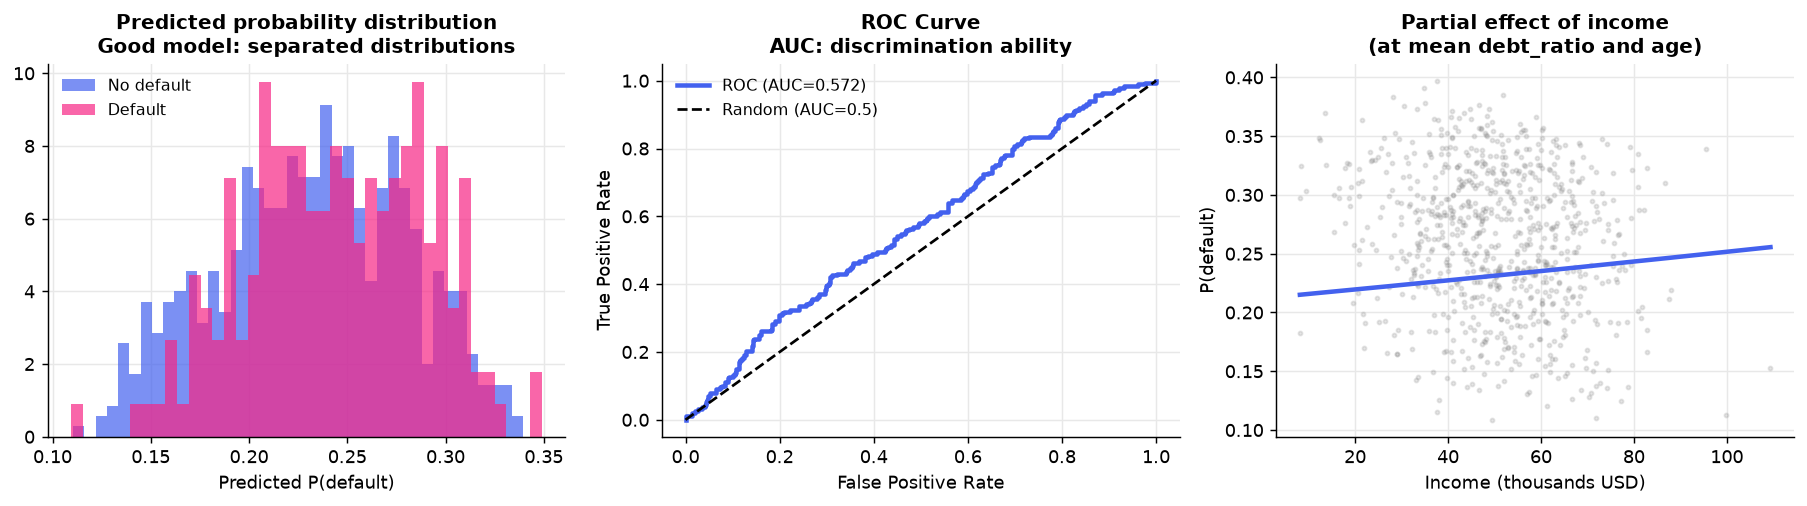

In [2]:
# ── Logistic regression: credit default prediction ────────────────────────
np.random.seed(1)
n = 800
income   = np.random.normal(50, 15, n)   # thousands USD
debt_ratio = np.random.beta(2, 5, n)
age      = np.random.normal(38, 10, n).clip(18, 75)

# True DGP: log-odds = -3 + 0.05*income_std - 2*debt_ratio - 0.03*age_std
income_s = (income - income.mean()) / income.std()
age_s    = (age - age.mean()) / age.std()
log_odds = -3 + 0.05*50 - 0.05*income_s - 2*debt_ratio - 0.03*age_s
p_default = 1 / (1 + np.exp(-log_odds))
default   = np.random.binomial(1, p_default)

df_cr = pd.DataFrame({'default': default, 'income': income,
                       'debt_ratio': debt_ratio, 'age': age})

X_cr = sm.add_constant(pd.DataFrame({'income_s': income_s, 'debt_ratio': debt_ratio, 'age_s': age_s}))
mod_logit = sm.Logit(default, X_cr).fit(disp=False)
print(mod_logit.summary())
print(f'\nOdds ratios:')
for name, coef in mod_logit.params.items():
    print(f'  {name:<15}: beta={coef:.4f}  OR={np.exp(coef):.4f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Predicted probabilities
pred_p = mod_logit.predict()
axes[0].hist(pred_p[default==0], bins=40, alpha=0.7, color='#4361ee', density=True, label='No default')
axes[0].hist(pred_p[default==1], bins=40, alpha=0.7, color='#f72585', density=True, label='Default')
axes[0].set_xlabel('Predicted P(default)')
axes[0].set_title('Predicted probability distribution\nGood model: separated distributions')
axes[0].legend(fontsize=9)

# ROC curve
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, _ = roc_curve(default, pred_p)
auc = roc_auc_score(default, pred_p)
axes[1].plot(fpr, tpr, color='#4361ee', lw=2.5, label=f'ROC (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1.5, label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve\nAUC: discrimination ability')
axes[1].legend(fontsize=9)

# Partial effect: P(default) vs income at mean debt_ratio and age
income_grid  = np.linspace(income.min(), income.max(), 200)
income_grid_s = (income_grid - income.mean()) / income.std()
X_grid = sm.add_constant(pd.DataFrame({'income_s': income_grid_s,
                                        'debt_ratio': np.full(200, debt_ratio.mean()),
                                        'age_s': np.zeros(200)}), has_constant='add')
p_grid = mod_logit.predict(X_grid)
axes[2].plot(income_grid, p_grid, color='#4361ee', lw=2.5)
axes[2].scatter(income, p_default, s=5, alpha=0.2, color='gray')
axes[2].set_xlabel('Income (thousands USD)'); axes[2].set_ylabel('P(default)')
axes[2].set_title('Partial effect of income\n(at mean debt_ratio and age)')
plt.tight_layout()
plt.show()

## Poisson regression

For count outcomes $Y_i \in \{0,1,2,\ldots\}$ with $E[Y_i] = \text{Var}(Y_i) = \mu_i$:
$$\log\mu_i = \mathbf{x}_i^\top\boldsymbol{\beta} \implies \mu_i = e^{\mathbf{x}_i^\top\boldsymbol{\beta}}$$

**Interpretation:** $e^{\beta_j}$ is the multiplicative change in the expected count for a
one-unit increase in $x_j$ — an **incidence rate ratio (IRR)**.

**Offset:** if exposure varies ($e_i$ person-years, $e_i$ hours), add $\log e_i$ as an offset
to model the *rate*: $\log(\mu_i/e_i) = \log e_i + \mathbf{x}_i^\top\boldsymbol{\beta}$

**Overdispersion:** when $\text{Var}(Y) > E[Y]$, Poisson is misspecified.
Use **Negative Binomial** or quasi-Poisson with robust SEs.

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  500
Model:                            GLM   Df Residuals:                      496
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1324.6
Date:                Mon, 29 Jun 2026   Deviance:                       486.65
Time:                        15:46:06   Pearson chi2:                     485.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9994
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0372      0.024     83.845      0.0

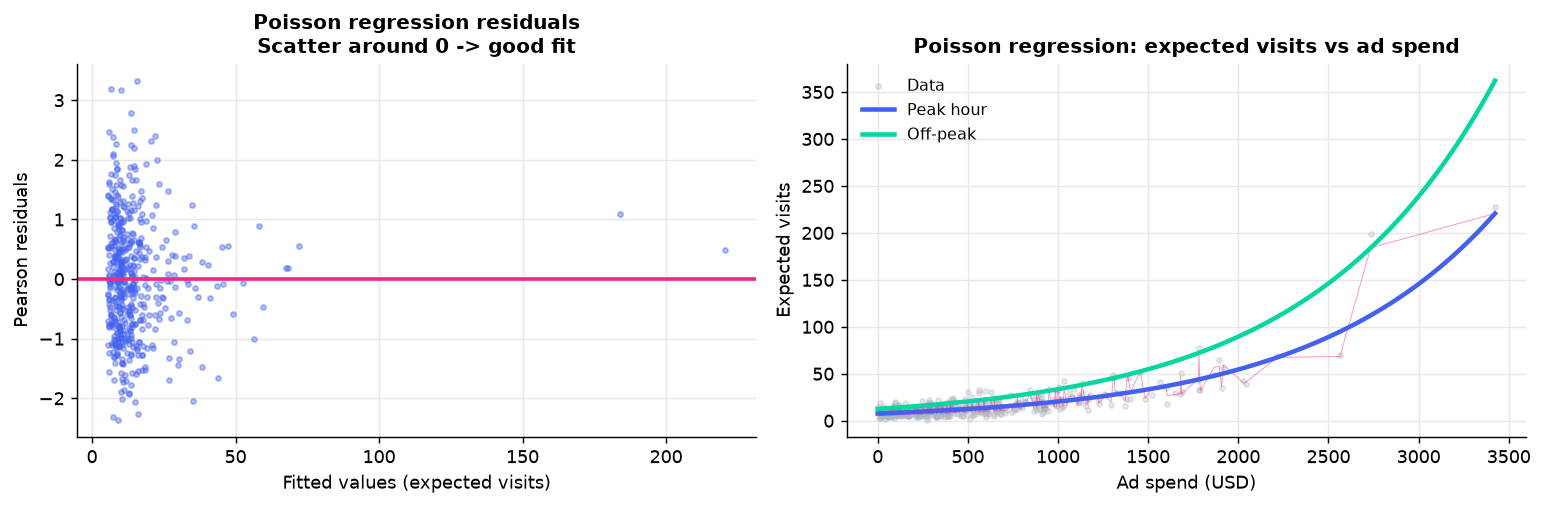

In [3]:
# ── Poisson regression: website visits ────────────────────────────────────
np.random.seed(3)
n_p = 500
ad_spend  = np.random.exponential(500, n_p)
mobile    = np.random.binomial(1, 0.6, n_p).astype(float)
hour      = np.random.choice(range(24), n_p)
peak_hour = ((hour >= 9) & (hour <= 17)).astype(float)

# True DGP: log(visits) = 2 + 0.001*ad - 0.3*mobile + 0.5*peak
log_mu = 2 + 0.001*ad_spend - 0.3*mobile + 0.5*peak_hour
visits = np.random.poisson(np.exp(log_mu))

X_p = sm.add_constant(pd.DataFrame({'ad_spend': ad_spend/1000, 'mobile': mobile, 'peak_hour': peak_hour}))
mod_pois = sm.GLM(visits, X_p, family=sm.families.Poisson()).fit()
print(mod_pois.summary())

print('\nIncidence Rate Ratios (IRR = exp(beta)):')
for name, coef in mod_pois.params.items():
    print(f'  {name:<12}: IRR={np.exp(coef):.4f}  ({(np.exp(coef)-1)*100:+.1f}% change in visits)')

# Check for overdispersion
pearson_resid = mod_pois.resid_pearson
dispersion = (pearson_resid**2).sum() / mod_pois.df_resid
print(f'\nDispersion statistic: {dispersion:.4f}  (1.0 = perfect Poisson; >1.5 = overdispersion)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(mod_pois.fittedvalues, pearson_resid, s=8, alpha=0.4, color='#4361ee')
axes[0].axhline(0, color='#f72585', lw=2)
axes[0].set_xlabel('Fitted values (expected visits)'); axes[0].set_ylabel('Pearson residuals')
axes[0].set_title('Poisson regression residuals\nScatter around 0 -> good fit')

axes[1].scatter(ad_spend, visits, s=8, alpha=0.3, color='#adb5bd', label='Data')
order = np.argsort(ad_spend)
axes[1].plot(ad_spend[order], mod_pois.fittedvalues[order], color='#f72585', lw=0.5, alpha=0.5)
peak_mask = peak_hour == 1
for mask, label, c in [(peak_mask, 'Peak hour', '#4361ee'), (~peak_mask, 'Off-peak', '#06d6a0')]:
    ad_g = np.linspace(ad_spend.min(), ad_spend.max(), 100)
    X_g = sm.add_constant(pd.DataFrame({'ad_spend': ad_g/1000, 'mobile': np.zeros(100), 'peak_hour': np.full(100, float(mask.mean()>0.5))}), has_constant='add')
    mu_g = mod_pois.predict(X_g)
    axes[1].plot(ad_g, mu_g, color=c, lw=2.5, label=label)
axes[1].set_xlabel('Ad spend (USD)'); axes[1].set_ylabel('Expected visits')
axes[1].set_title('Poisson regression: expected visits vs ad spend')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()